In [2]:
import numpy as np

arr_1d = np.array([1, 2, 3, 4, 5])
print("一维数组：\n", arr_1d, "形状：", arr_1d.shape)
arr_2d = np.array([[1,2,3], [4,5,6], [7,8,9]])
print("\n二维数组：\n", arr_2d, "形状：", arr_2d.shape)
arr_3d = np.array([[[1,2],[3,4]],[[5,6],[7,8]]])
print("\n三维数组：\n", arr_3d, "形状：", arr_3d.shape)

print("1D取第2-4位：", arr_1d[1:4])
print("2D第二行第三列：", arr_2d[1,2])
print("2D前两行前两列：\n", arr_2d[:2, :2])
print("3D第一层第二行：", arr_3d[0,1,:])

reshape_arr = arr_1d.reshape((5,1))
print("1D转为5行1列：\n", reshape_arr)
flatten_arr = arr_2d.flatten()
print("2D展平一维：", flatten_arr)
T_arr = arr_2d.T
print("二维数组转置：\n", T_arr)

def mat_add(a, b):
    """矩阵加法"""
    return np.add(a, b)

def mat_mul(a, b):
    """矩阵乘法（点积）"""
    return np.dot(a, b)

def mat_transpose(a):
    """矩阵转置"""
    return a.T

mat1 = np.array([[1,2],[3,4]])
mat2 = np.array([[5,6],[7,8]])
print("矩阵加法：\n", mat_add(mat1, mat2))
print("矩阵乘法：\n", mat_mul(mat1, mat2))
print("矩阵转置：\n", mat_transpose(mat1))

rand_data = np.random.normal(loc=10, scale=3, size=(100,))
print("\n===== 随机数据统计 =====")
print("均值：", np.mean(rand_data))
print("方差：", np.var(rand_data))
print("标准差：", np.std(rand_data))
print("最大值：", np.max(rand_data))
print("最小值：", np.min(rand_data))
print("中位数：", np.median(rand_data))

一维数组：
 [1 2 3 4 5] 形状： (5,)

二维数组：
 [[1 2 3]
 [4 5 6]
 [7 8 9]] 形状： (3, 3)

三维数组：
 [[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]] 形状： (2, 2, 2)
1D取第2-4位： [2 3 4]
2D第二行第三列： 6
2D前两行前两列：
 [[1 2]
 [4 5]]
3D第一层第二行： [3 4]
1D转为5行1列：
 [[1]
 [2]
 [3]
 [4]
 [5]]
2D展平一维： [1 2 3 4 5 6 7 8 9]
二维数组转置：
 [[1 4 7]
 [2 5 8]
 [3 6 9]]
矩阵加法：
 [[ 6  8]
 [10 12]]
矩阵乘法：
 [[19 22]
 [43 50]]
矩阵转置：
 [[1 3]
 [2 4]]

===== 随机数据统计 =====
均值： 10.320178199634835
方差： 7.697453201428415
标准差： 2.774428445901681
最大值： 19.21280526957367
最小值： 4.1740551080447
中位数： 10.181913049120816


两只股票的年化波动率： [0.15921294 0.13440926]
投资组合方差： 4.6610320091902375e-05
收益率协方差矩阵：
 [[1.00992679e-04 6.73598322e-06]
 [6.73598322e-06 7.19766353e-05]]


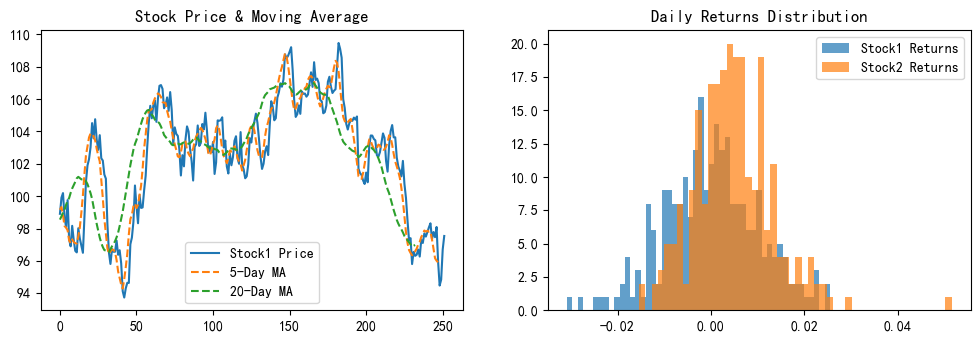

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)  
days = 252 
price_1 = 100 + np.cumsum(np.random.normal(0, 1, days))
price_2 = 80 + np.cumsum(np.random.normal(0.8, 1.2, days))
prices = np.vstack([price_1, price_2]).T  # 组合成形状为(252,2)的价格数组

daily_returns = prices[1:] / prices[:-1] - 1
annual_volatility = np.std(daily_returns, axis=0) * np.sqrt(252)
print("两只股票的年化波动率：", annual_volatility)

def moving_average(data, window_size):
    """计算简单移动平均线"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')


ma5_stock1 = moving_average(price_1, 5)
ma20_stock1 = moving_average(price_1, 20)

weights = np.array([0.5, 0.5])
portfolio_variance = np.dot(weights.T, np.dot(np.cov(daily_returns.T), weights))
cov_matrix = np.cov(daily_returns.T)
print("投资组合方差：", portfolio_variance)
print("收益率协方差矩阵：\n", cov_matrix)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False 
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(price_1, label='Stock1 Price')
plt.plot(ma5_stock1, label='5-Day MA', linestyle='--')
plt.plot(ma20_stock1, label='20-Day MA', linestyle='--')
plt.title("Stock Price & Moving Average")
plt.legend()
plt.subplot(2, 2, 2)
plt.hist(daily_returns[:,0], bins=50, alpha=0.7, label='Stock1 Returns')
plt.hist(daily_returns[:,1], bins=50, alpha=0.7, label='Stock2 Returns')
plt.title("Daily Returns Distribution")
plt.legend();

